# kNN Dominant Flavor Classifier — UVA Dining Data

Trains a k-Nearest Neighbors classifier to predict a food item's **dominant flavor** — whichever of the 6 flavor scores (`sweet`, `salty`, `savory`, `spicy`, `sour`, `rich`) is highest.

**Hyperparameters** tuned via grid search on the validation set:
- `k` (n_neighbors) — number of nearest neighbors
- `weights` — `uniform` (equal vote) vs `distance` (closer neighbors count more)
- `metric` / `p` — distance function: Manhattan (p=1), Euclidean (p=2), Cubic Minkowski (p=3)
- `scaler` — StandardScaler vs MinMaxScaler vs no scaling

**Data split:** ~75% training / ~15% validation / ~10% testing (a day's worth of menu items)

**Directory structure:**
- `DATA_DIR` — where the individual categorized CSV files live (input, read-only)
- `OUTPUT_DIR` — where the concatenated CSV and train/val/test splits are saved (output)


## 1. Imports

In [1]:
import os
import re
import glob
import random
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

sns.set_style("whitegrid")
%matplotlib inline


## 2. Configuration

- `DATA_DIR` — folder with individual categorized CSV files (e.g., `3-30-2026-Breakfast_filled.csv`)
- `OUTPUT_DIR` — folder where concatenated and split CSVs are saved


In [2]:
# Directory containing the individual categorized CSV files (input)
DATA_DIR = "./CategorizedData"

# Directory where concatenated CSV and train/val/test splits are saved (output)
OUTPUT_DIR = "./ondemand"

# Flavor profile feature columns (also used to derive the target label)
FEATURE_COLUMNS = ["sweet", "salty", "savory", "spicy", "sour", "rich"]

# Column that identifies individual items
ITEM_NAME_COLUMN = "name"

# Target label column (created automatically)
TARGET_COLUMN = "dominant_flavor"

# Random seed for reproducibility
RANDOM_SEED = 42

# Hyperparameter grid for grid search
PARAM_GRID = {
    "n_neighbors": [1, 3, 5, 7, 9, 11, 15, 19, 25],
    "weights":     ["uniform", "distance"],
    "metric":      ["minkowski"],
    "p":           [1, 2, 3],           # 1=Manhattan, 2=Euclidean, 3=cubic
    "scaler":      ["standard", "minmax", "none"],
}

# Create output directory if it doesn't exist
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Input directory:  {os.path.abspath(DATA_DIR)}")
print(f"Output directory: {os.path.abspath(OUTPUT_DIR)}")


Input directory:  /sfs/gpfs/tardis/home/jrn2kf/CategorizedData
Output directory: /sfs/gpfs/tardis/home/jrn2kf/ondemand


## 3. Data Loading

Loads all individual CSV files from `DATA_DIR`, concatenates them, and saves the
combined result to `OUTPUT_DIR/all_items_combined.csv`.


In [3]:
def parse_date_from_filename(filename: str) -> str:
    """Extract the date portion from filenames like '3-30-2026-Breakfast_filled.csv'."""
    base = os.path.basename(filename)
    match = re.match(r"(\d{1,2}-\d{1,2}-\d{4})", base)
    return match.group(1) if match else base


def parse_meal_from_filename(filename: str) -> str:
    """Extract 'Breakfast', 'Lunch', or 'Dinner' from the filename."""
    base = os.path.basename(filename)
    for meal in ["Breakfast", "Lunch", "Dinner"]:
        if meal in base:
            return meal
    return "Unknown"


def load_all_csvs(data_dir: str, output_dir: str) -> pd.DataFrame:
    """
    Load and concatenate all CSV files from data_dir.
    Saves the concatenated result to output_dir/all_items_combined.csv.
    """
    csv_pattern = os.path.join(data_dir, "*.csv")
    csv_files = sorted(glob.glob(csv_pattern))

    if not csv_files:
        raise FileNotFoundError(
            f"No CSV files found in '{data_dir}'. "
            f"Please place your categorized data CSVs in that folder."
        )

    frames = []
    for filepath in csv_files:
        df = pd.read_csv(filepath)
        df["source_file"] = os.path.basename(filepath)
        df["date"] = parse_date_from_filename(filepath)
        df["meal"] = parse_meal_from_filename(filepath)
        frames.append(df)
        print(f"  Loaded {os.path.basename(filepath):45s} — {len(df):>4d} rows")

    combined = pd.concat(frames, ignore_index=True)
    print(f"\n  Total rows loaded: {len(combined)}")

    # Save the concatenated dataframe to the output directory
    combined_path = os.path.join(output_dir, "all_items_combined.csv")
    combined.to_csv(combined_path, index=False)
    print(f"  Saved concatenated CSV → {combined_path}")

    return combined


df = load_all_csvs(DATA_DIR, OUTPUT_DIR)
df.head()


  Loaded 3-30-2026-Breakfast_filled.csv                —   38 rows
  Loaded 3-30-2026-Dinner_filled.csv                   —   59 rows
  Loaded 3-30-2026-Lunch_filled.csv                    —   59 rows
  Loaded 3-31-2026-Breakfast_filled.csv                —   37 rows
  Loaded 3-31-2026-Dinner_filled.csv                   —   68 rows
  Loaded 3-31-2026-Lunch_filled.csv                    —   72 rows
  Loaded 4-01-2026-Breakfast_filled.csv                —   37 rows
  Loaded 4-01-2026-Dinner_filled.csv                   —   59 rows
  Loaded 4-01-2026-Lunch_filled.csv                    —   58 rows
  Loaded 4-02-2026-Breakfast_filled.csv                —   39 rows
  Loaded 4-02-2026-Dinner_filled.csv                   —   60 rows
  Loaded 4-02-2026-Lunch_filled.csv                    —   70 rows
  Loaded 4-03-2026-Breakfast_filled.csv                —   39 rows
  Loaded 4-03-2026-Dinner_filled.csv                   —   57 rows
  Loaded 4-03-2026-Lunch_filled.csv                    —   70 

,name,category,description,ingredients,diet_tags,allergens,sweet,salty,savory,spicy,sour,rich,source_file,date,meal
0,Hard-Cooked Egg,Omelet/Quiche/Frittata/Strata,"Perfectly hard-cooked egg, featuring a firm ye...","Water, Egg",NaN,NaN,0.1,0.3,2.1,0.0,0.0,2.6,3-30-2026-Breakfast_filled.csv,3-30-2026,Breakfast
1,Scrambled Just® Egg,Omelet/Quiche/Frittata/Strata,Scrambled Just® egg seasoned with salt & pepper,"Plant Based Egg (Water, Mung Bean Protein, Exp...",NaN,NaN,0.1,0.8,1.8,0.1,0.0,1.7,3-30-2026-Breakfast_filled.csv,3-30-2026,Breakfast
2,Scrambled Eggs,Omelet/Quiche/Frittata/Strata,Eggs gently scrambled to fluffy perfection,"Egg Blend (WHOLE EGGS, 19.0% WATER. CONTAINS 2...",NaN,NaN,0.1,0.4,2.3,0.0,0.1,2.2,3-30-2026-Breakfast_filled.csv,3-30-2026,Breakfast
3,"Egg, Sausage & Cheese Bagel",Breakfast,"Scrambled egg, breakfast sausage and American ...","Bagel, Egg Blend, Sausage Patty, American Chee...",NaN,NaN,0.7,2.8,3.8,0.2,0.1,3.2,3-30-2026-Breakfast_filled.csv,3-30-2026,Breakfast
4,Turkey Sausage Link,Breakfast Meat,Golden brown savory turkey sausage link,"Turkey Sausage (Turkey, Mechanically Separated...",NaN,NaN,0.3,2.2,3.4,0.4,0.1,2.4,3-30-2026-Breakfast_filled.csv,3-30-2026,Breakfast


## 4. Data Cleaning & Dominant Flavor Labels

For each item, the **dominant flavor** is whichever of the 6 flavor scores is
highest. Items with all-zero scores are labeled `neutral`.


In [4]:
def clean_and_label(df: pd.DataFrame) -> pd.DataFrame:
    """Clean data and create the dominant-flavor target label."""
    df = df.copy()

    # Drop rows with missing flavor values
    before = len(df)
    df = df.dropna(subset=FEATURE_COLUMNS)
    dropped = before - len(df)
    if dropped > 0:
        print(f"  Dropped {dropped} rows with missing flavor values.")

    # Derive the dominant flavor label
    flavor_values = df[FEATURE_COLUMNS]
    df[TARGET_COLUMN] = flavor_values.idxmax(axis=1)

    # Handle all-zero edge case
    all_zero_mask = flavor_values.sum(axis=1) == 0
    if all_zero_mask.any():
        df.loc[all_zero_mask, TARGET_COLUMN] = "neutral"
        print(f"  Note: {all_zero_mask.sum()} items with all-zero scores → 'neutral'.")

    return df


df = clean_and_label(df)
print(f"\nTotal usable items: {len(df)}")
df[[ITEM_NAME_COLUMN] + FEATURE_COLUMNS + [TARGET_COLUMN]].head(10)



Total usable items: 1677


,name,sweet,salty,savory,spicy,sour,rich,dominant_flavor
0,Hard-Cooked Egg,0.1,0.3,2.1,0.0,0.0,2.6,rich
1,Scrambled Just® Egg,0.1,0.8,1.8,0.1,0.0,1.7,savory
2,Scrambled Eggs,0.1,0.4,2.3,0.0,0.1,2.2,savory
3,"Egg, Sausage & Cheese Bagel",0.7,2.8,3.8,0.2,0.1,3.2,savory
4,Turkey Sausage Link,0.3,2.2,3.4,0.4,0.1,2.4,savory
5,Pork Sausage Links,0.2,2.1,3.7,0.2,0.1,3.0,savory
6,Hash Brown Potatoes,0.2,1.7,2.4,0.2,0.1,1.8,savory
7,O'Brien Potatoes,0.4,1.7,2.5,0.2,0.2,1.7,savory
8,Pancake,2.2,0.5,0.3,0.0,0.1,0.8,sweet
9,Buttermilk Pancakes,2.3,0.6,0.4,0.0,0.4,1.1,sweet


### Dominant Flavor Distribution

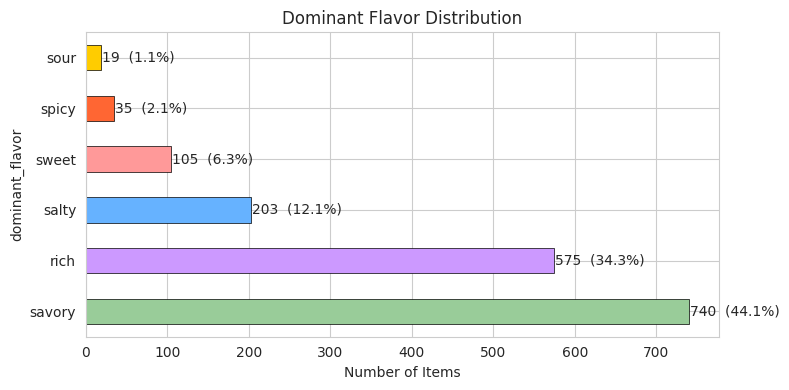

In [5]:
label_counts = df[TARGET_COLUMN].value_counts()

fig, ax = plt.subplots(figsize=(8, 4))
colors = {"sweet": "#FF9999", "salty": "#66B2FF", "savory": "#99CC99",
          "spicy": "#FF6633", "sour": "#FFCC00", "rich": "#CC99FF", "neutral": "#CCCCCC"}
bar_colors = [colors.get(l, "#888888") for l in label_counts.index]

label_counts.plot(kind="barh", ax=ax, color=bar_colors, edgecolor="black", linewidth=0.5)
ax.set_xlabel("Number of Items")
ax.set_title("Dominant Flavor Distribution")
for i, (count, label) in enumerate(zip(label_counts.values, label_counts.index)):
    ax.text(count + 1, i, f"{count}  ({count/len(df)*100:.1f}%)", va="center", fontsize=10)
plt.tight_layout()
plt.show()


## 5. Train / Validation / Test Split

The **test set** simulates a day's worth of dining — items are sampled
proportionally by meal (breakfast, lunch, dinner) from one date (~10% of data).

The split CSVs are saved to `OUTPUT_DIR`:
- `train_split.csv`
- `validation_split.csv`
- `test_split.csv`


In [6]:
def split_data(df, train_ratio=0.75, val_ratio=0.15, test_ratio=0.10, seed=42):
    """Split data into train/val/test. Test set = one day's menu sample."""
    rng = random.Random(seed)
    np.random.seed(seed)

    n_total = len(df)
    target_test_size = int(round(n_total * test_ratio))

    dates = df["date"].unique().tolist()
    day_sizes = {d: len(df[df["date"] == d]) for d in dates}

    print("Available dates:")
    for d in sorted(dates):
        meals = df[df["date"] == d]["meal"].unique()
        print(f"  {d}: {day_sizes[d]} items  (meals: {', '.join(sorted(meals))})")

    best_day = min(dates, key=lambda d: abs(day_sizes[d] - target_test_size))
    day_df = df[df["date"] == best_day]

    if day_sizes[best_day] <= target_test_size * 2:
        df_test = day_df.reset_index(drop=True)
        print(f"\nTest day: {best_day} ({day_sizes[best_day]} items, used in full)")
    else:
        print(f"\nDay {best_day} has {day_sizes[best_day]} items "
              f"(target ~{target_test_size}). Sampling by meal...")
        test_parts = []
        meal_counts = day_df["meal"].value_counts(normalize=True)
        for meal in day_df["meal"].unique():
            meal_df = day_df[day_df["meal"] == meal]
            n_from_meal = max(1, int(round(meal_counts[meal] * target_test_size)))
            n_from_meal = min(n_from_meal, len(meal_df))
            test_parts.append(meal_df.sample(n=n_from_meal, random_state=seed))
        df_test = pd.concat(test_parts).reset_index(drop=True)
        if len(df_test) > target_test_size:
            df_test = df_test.sample(n=target_test_size, random_state=seed).reset_index(drop=True)
        print(f"Sampled {len(df_test)} items from {best_day}")

    # Exclude test items from remaining data
    test_keys = set(
        zip(df_test[ITEM_NAME_COLUMN], df_test["date"], df_test["meal"],
            df_test["sweet"], df_test["salty"])
    )
    remaining_mask = ~df.apply(
        lambda r: (r[ITEM_NAME_COLUMN], r["date"], r["meal"],
                   r["sweet"], r["salty"]) in test_keys,
        axis=1,
    )
    remaining = df[remaining_mask].sample(frac=1, random_state=seed).reset_index(drop=True)

    effective_train_ratio = train_ratio / (train_ratio + val_ratio)
    n_train = int(round(len(remaining) * effective_train_ratio))

    df_train = remaining.iloc[:n_train].reset_index(drop=True)
    df_val = remaining.iloc[n_train:].reset_index(drop=True)

    return df_train, df_val, df_test


df_train, df_val, df_test = split_data(df, 0.75, 0.15, 0.10, RANDOM_SEED)

print(f"\nTraining set:    {len(df_train):>4d} items  ({len(df_train)/len(df)*100:.1f}%)")
print(f"Validation set:  {len(df_val):>4d} items  ({len(df_val)/len(df)*100:.1f}%)")
print(f"Test set (day):  {len(df_test):>4d} items  ({len(df_test)/len(df)*100:.1f}%)")

for label, subset in [("Train", df_train), ("Val", df_val), ("Test", df_test)]:
    counts = Counter(subset[TARGET_COLUMN].values)
    summary = ", ".join(f"{k}: {v}" for k, v in counts.most_common())
    print(f"  {label:5s} — {summary}")

# Save split CSVs to output directory
df_train.to_csv(os.path.join(OUTPUT_DIR, "train_split.csv"), index=False)
df_val.to_csv(os.path.join(OUTPUT_DIR, "validation_split.csv"), index=False)
df_test.to_csv(os.path.join(OUTPUT_DIR, "test_split.csv"), index=False)
print(f"\nSaved split CSVs to '{OUTPUT_DIR}/':")
print(f"  train_split.csv       ({len(df_train)} items)")
print(f"  validation_split.csv  ({len(df_val)} items)")
print(f"  test_split.csv        ({len(df_test)} items)")


Available dates:
  3-30-2026: 156 items  (meals: Breakfast, Dinner, Lunch)
  3-31-2026: 177 items  (meals: Breakfast, Dinner, Lunch)
  4-01-2026: 154 items  (meals: Breakfast, Dinner, Lunch)
  4-02-2026: 169 items  (meals: Breakfast, Dinner, Lunch)
  4-03-2026: 166 items  (meals: Breakfast, Dinner, Lunch)
  4-04-2026: 177 items  (meals: Breakfast, Dinner, Lunch)
  4-05-2026: 183 items  (meals: Breakfast, Dinner, Lunch)
  4-06-2026: 163 items  (meals: Breakfast, Dinner, Lunch)
  4-07-2026: 167 items  (meals: Breakfast, Dinner, Lunch)
  4-08-2026: 165 items  (meals: Breakfast, Dinner, Lunch)

Test day: 4-02-2026 (169 items, used in full)

Training set:    1257 items  (75.0%)
Validation set:   251 items  (15.0%)
Test set (day):   169 items  (10.1%)
  Train — savory: 558, rich: 427, salty: 153, sweet: 79, spicy: 25, sour: 15
  Val   — savory: 114, rich: 82, salty: 32, sweet: 16, spicy: 6, sour: 1
  Test  — savory: 68, rich: 66, salty: 18, sweet: 10, spicy: 4, sour: 3

Saved split CSVs to '

## 6. Feature Extraction

In [7]:
X_train_raw = df_train[FEATURE_COLUMNS].values.astype(float)
y_train     = df_train[TARGET_COLUMN].values

X_val_raw   = df_val[FEATURE_COLUMNS].values.astype(float)
y_val       = df_val[TARGET_COLUMN].values

X_test_raw  = df_test[FEATURE_COLUMNS].values.astype(float)
y_test      = df_test[TARGET_COLUMN].values

print(f"X_train shape: {X_train_raw.shape}")
print(f"X_val shape:   {X_val_raw.shape}")
print(f"X_test shape:  {X_test_raw.shape}")
print(f"Classes:       {sorted(set(y_train))}")


X_train shape: (1257, 6)
X_val shape:   (251, 6)
X_test shape:  (169, 6)
Classes:       ['rich', 'salty', 'savory', 'sour', 'spicy', 'sweet']


## 7. Scaling Helpers

In [8]:
def get_scaler(scaler_name: str):
    """Return a scaler instance (or None) based on name."""
    if scaler_name == "standard":
        return StandardScaler()
    elif scaler_name == "minmax":
        return MinMaxScaler()
    return None


def scale_features(X_train, X_val, X_test, scaler_name: str):
    """Fit scaler on training data and transform all splits."""
    scaler = get_scaler(scaler_name)
    if scaler is not None:
        X_train_s = scaler.fit_transform(X_train)
        X_val_s   = scaler.transform(X_val)
        X_test_s  = scaler.transform(X_test)
    else:
        X_train_s = X_train.copy()
        X_val_s   = X_val.copy()
        X_test_s  = X_test.copy()
    return X_train_s, X_val_s, X_test_s, scaler


## 8. Hyperparameter Grid Search

Exhaustively evaluates all combinations of `k`, `weights`, `p` (distance metric),
and `scaler` on the validation set.


In [9]:
def grid_search(X_train_raw, y_train, X_val_raw, y_val, X_test_raw, param_grid):
    """Exhaustive grid search. Returns best params, model, scaled data, and results."""
    keys = list(param_grid.keys())
    combos = list(itertools.product(*[param_grid[k] for k in keys]))

    print(f"Evaluating {len(combos)} hyperparameter combinations...")

    results = []
    best_acc = -1
    best_entry = None

    for combo in combos:
        params = dict(zip(keys, combo))

        X_tr, X_va, X_te, scaler = scale_features(
            X_train_raw, X_val_raw, X_test_raw, params["scaler"]
        )

        model = KNeighborsClassifier(
            n_neighbors=params["n_neighbors"],
            weights=params["weights"],
            metric=params["metric"],
            p=params["p"],
        )
        model.fit(X_tr, y_train)
        val_acc = accuracy_score(y_val, model.predict(X_va))

        entry = {**params, "val_accuracy": val_acc}
        results.append(entry)

        if val_acc > best_acc:
            best_acc = val_acc
            best_entry = entry
            best_model = model
            best_X_train = X_tr
            best_X_val = X_va
            best_X_test = X_te

    results_df = pd.DataFrame(results).sort_values("val_accuracy", ascending=False)
    return best_entry, best_model, best_X_train, best_X_val, best_X_test, results_df


best_params, best_model, X_train, X_val, X_test, results_df = grid_search(
    X_train_raw, y_train, X_val_raw, y_val, X_test_raw, PARAM_GRID
)

print("\nTop 15 hyperparameter combinations:")
results_df.head(15)


Evaluating 162 hyperparameter combinations...

Top 15 hyperparameter combinations:


,n_neighbors,weights,metric,p,scaler,val_accuracy
6,1,uniform,minkowski,3,standard,0.972112
3,1,uniform,minkowski,2,standard,0.972112
15,1,distance,minkowski,3,standard,0.972112
17,1,distance,minkowski,3,none,0.972112
8,1,uniform,minkowski,3,none,0.972112
12,1,distance,minkowski,2,standard,0.972112
35,3,distance,minkowski,3,none,0.972112
32,3,distance,minkowski,2,none,0.968127
7,1,uniform,minkowski,3,minmax,0.968127
16,1,distance,minkowski,3,minmax,0.968127


### Best Hyperparameters

In [10]:
p_names = {1: "Manhattan", 2: "Euclidean", 3: "Cubic Minkowski"}

p_val = best_params['p']
dist_name = p_names.get(p_val, f"Minkowski p={p_val}")

print(f"k (n_neighbors) = {best_params['n_neighbors']}")
print(f"weights         = {best_params['weights']}")
print(f"distance        = {dist_name} (p={p_val})")
print(f"scaler          = {best_params['scaler']}")
print(f"val accuracy    = {best_params['val_accuracy']:.4f}")


k (n_neighbors) = 1
weights         = uniform
distance        = Euclidean (p=2)
scaler          = standard
val accuracy    = 0.9721


### Validation Accuracy vs k

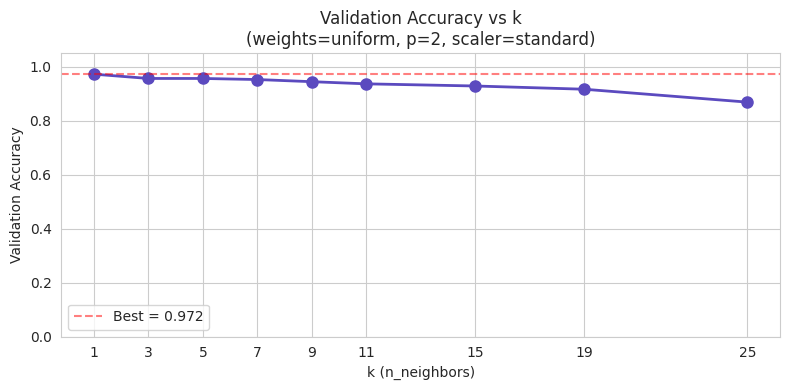

In [11]:
# Filter to the best weight/p/scaler combo and plot accuracy vs k
best_w = best_params["weights"]
best_p = best_params["p"]
best_s = best_params["scaler"]

subset = results_df[
    (results_df["weights"] == best_w) &
    (results_df["p"] == best_p) &
    (results_df["scaler"] == best_s)
].sort_values("n_neighbors")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(subset["n_neighbors"], subset["val_accuracy"], "o-", color="#5B4ABF", linewidth=2, markersize=8)
ax.set_xlabel("k (n_neighbors)")
ax.set_ylabel("Validation Accuracy")
ax.set_title(f"Validation Accuracy vs k\n(weights={best_w}, p={best_p}, scaler={best_s})")
ax.set_xticks(subset["n_neighbors"])
ax.set_ylim(0, 1.05)
ax.axhline(y=best_params["val_accuracy"], color="red", linestyle="--", alpha=0.5, label=f"Best = {best_params['val_accuracy']:.3f}")
ax.legend()
plt.tight_layout()
plt.show()


## 9. Model Evaluation

In [12]:
def evaluate_model(model, X, y, set_name="Test"):
    """Print classification report and return accuracy."""
    y_pred = model.predict(X)
    acc = accuracy_score(y, y_pred)

    print(f"\n{'='*60}")
    print(f"  {set_name} Set — Accuracy: {acc:.4f} ({acc*100:.1f}%)")
    print(f"{'='*60}")

    labels = sorted(set(y) | set(y_pred))
    print(classification_report(y, y_pred, labels=labels, zero_division=0))

    return acc, y_pred


### Training Set

In [13]:
train_acc, _ = evaluate_model(best_model, X_train, y_train, "Training")



  Training Set — Accuracy: 1.0000 (100.0%)
              precision    recall  f1-score   support

        rich       1.00      1.00      1.00       427
       salty       1.00      1.00      1.00       153
      savory       1.00      1.00      1.00       558
        sour       1.00      1.00      1.00        15
       spicy       1.00      1.00      1.00        25
       sweet       1.00      1.00      1.00        79

    accuracy                           1.00      1257
   macro avg       1.00      1.00      1.00      1257
weighted avg       1.00      1.00      1.00      1257



### Validation Set

In [14]:
val_acc, _ = evaluate_model(best_model, X_val, y_val, "Validation")



  Validation Set — Accuracy: 0.9721 (97.2%)
              precision    recall  f1-score   support

        rich       0.96      0.96      0.96        82
       salty       0.97      0.94      0.95        32
      savory       0.97      0.99      0.98       114
        sour       0.00      0.00      0.00         1
       spicy       1.00      1.00      1.00         6
       sweet       1.00      1.00      1.00        16

    accuracy                           0.97       251
   macro avg       0.82      0.82      0.82       251
weighted avg       0.97      0.97      0.97       251



### Test Set (Day's Menu)

In [15]:
test_acc, y_test_pred = evaluate_model(best_model, X_test, y_test, "Test (Day's Menu)")



  Test (Day's Menu) Set — Accuracy: 0.9704 (97.0%)
              precision    recall  f1-score   support

        rich       0.98      0.95      0.97        66
       salty       0.94      0.94      0.94        18
      savory       0.97      0.99      0.98        68
        sour       1.00      1.00      1.00         3
       spicy       1.00      1.00      1.00         4
       sweet       0.91      1.00      0.95        10

    accuracy                           0.97       169
   macro avg       0.97      0.98      0.97       169
weighted avg       0.97      0.97      0.97       169



### Confusion Matrix — Test Set

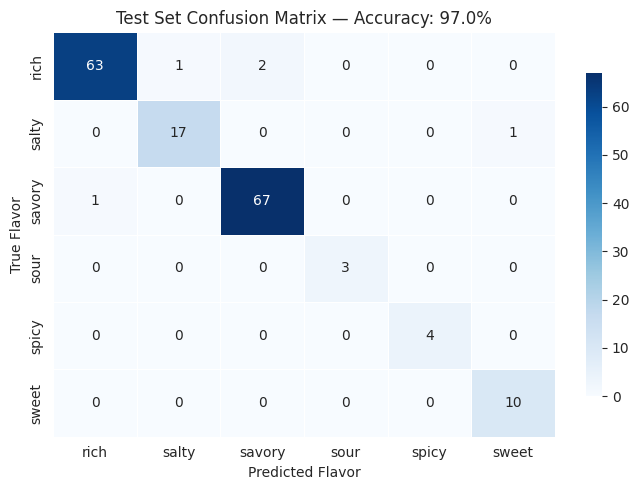

In [16]:
labels = sorted(set(y_test) | set(y_test_pred))
cm = confusion_matrix(y_test, y_test_pred, labels=labels)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels,
            yticklabels=labels, ax=ax, linewidths=0.5, cbar_kws={"shrink": 0.8})
ax.set_xlabel("Predicted Flavor")
ax.set_ylabel("True Flavor")
ax.set_title(f"Test Set Confusion Matrix — Accuracy: {test_acc:.1%}")
plt.tight_layout()
plt.show()


## 10. Test Day — Item-by-Item Predictions

Each row shows the item name, its true dominant flavor, the model's prediction,
and all 6 flavor scores for context.


In [17]:
# Build a detailed results dataframe
results_detail = df_test[[ITEM_NAME_COLUMN, "meal", TARGET_COLUMN] + FEATURE_COLUMNS].copy()
results_detail["predicted"] = y_test_pred
results_detail["correct"] = results_detail[TARGET_COLUMN] == results_detail["predicted"]

# Sort by meal order
meal_order = {"Breakfast": 0, "Lunch": 1, "Dinner": 2, "Unknown": 3}
results_detail["_sort"] = results_detail["meal"].map(meal_order)
results_detail = results_detail.sort_values("_sort").drop(columns="_sort")

# Display
correct_count = results_detail["correct"].sum()
total = len(results_detail)

for meal in ["Breakfast", "Lunch", "Dinner"]:
    meal_items = results_detail[results_detail["meal"] == meal]
    if meal_items.empty:
        continue
    print(f"\n--- {meal} ---")
    for _, row in meal_items.iterrows():
        mark = "✓" if row["correct"] else "✗"
        scores = " ".join(f"{c[:3]}={row[c]:.1f}" for c in FEATURE_COLUMNS)
        print(f"  {mark}  {str(row[ITEM_NAME_COLUMN]):40s}  "
              f"true={str(row[TARGET_COLUMN]):8s}  pred={str(row['predicted']):8s}  [{scores}]")

print(f"\nDay accuracy: {correct_count}/{total} ({correct_count/total*100:.1f}%)")



--- Breakfast ---
  ✓  Smoked  Maple Sausage                     true=salty     pred=salty     [swe=3.6 sal=3.8 sav=3.2 spi=1.2 sou=0.8 ric=2.5]
  ✓  Hard-Cooked Egg                           true=rich      pred=rich      [swe=1.3 sal=2.5 sav=4.8 spi=1.4 sou=0.3 ric=5.0]
  ✓  Scrambled Just® Egg                       true=savory    pred=savory    [swe=1.9 sal=2.6 sav=3.9 spi=2.8 sou=1.5 ric=1.8]
  ✓  Scrambled Eggs                            true=savory    pred=savory    [swe=1.3 sal=4.1 sav=4.4 spi=1.0 sou=0.9 ric=3.0]
  ✓  Egg White Ham English Muffin              true=salty     pred=salty     [swe=2.7 sal=5.0 sav=4.0 spi=1.1 sou=0.1 ric=1.5]
  ✓  Turkey Sausage Patty                      true=salty     pred=salty     [swe=2.9 sal=4.5 sav=2.8 spi=0.2 sou=0.4 ric=2.4]
  ✓  O'Brien Potatoes                          true=rich      pred=rich      [swe=0.8 sal=4.1 sav=4.4 spi=2.4 sou=1.3 ric=5.0]
  ✓  Crispy Tater Tots                         true=rich      pred=rich      [swe=0.6 sal=3.

## 11. Feature Importance

Permutation-based importance: for each feature, shuffle its column in the
validation set and measure how much accuracy drops. A larger drop means that
feature is more important.


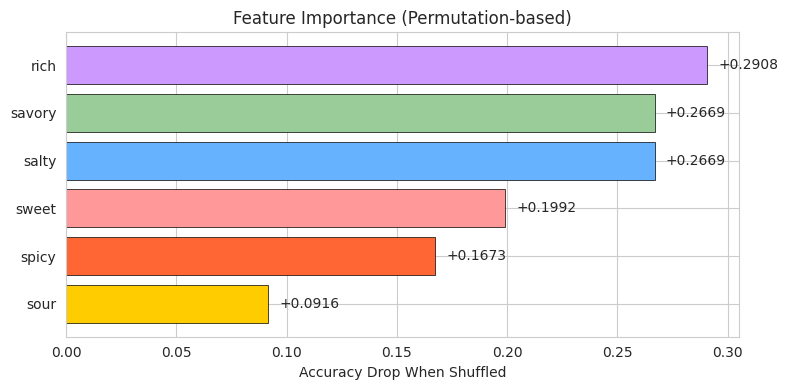

In [18]:
np.random.seed(RANDOM_SEED)
baseline_acc = accuracy_score(y_val, best_model.predict(X_val))
importances = {}

for i, feat in enumerate(FEATURE_COLUMNS):
    X_val_perm = X_val.copy()
    np.random.shuffle(X_val_perm[:, i])
    perm_acc = accuracy_score(y_val, best_model.predict(X_val_perm))
    importances[feat] = baseline_acc - perm_acc

# Sort and plot
imp_sorted = dict(sorted(importances.items(), key=lambda x: x[1]))

fig, ax = plt.subplots(figsize=(8, 4))
colors_imp = [colors.get(f, "#888") for f in imp_sorted.keys()]
ax.barh(list(imp_sorted.keys()), list(imp_sorted.values()), color=colors_imp,
        edgecolor="black", linewidth=0.5)
ax.set_xlabel("Accuracy Drop When Shuffled")
ax.set_title("Feature Importance (Permutation-based)")
ax.axvline(x=0, color="black", linewidth=0.5)
for i, (feat, val) in enumerate(imp_sorted.items()):
    ax.text(val + 0.005, i, f"{val:+.4f}", va="center", fontsize=10)
plt.tight_layout()
plt.show()


## 12. Summary

In [19]:
p_name = p_names.get(best_params["p"], f"Minkowski p={best_params['p']}")

summary = {
    "Classification Target": f"Dominant flavor ({', '.join(FEATURE_COLUMNS)})",
    "Best k (n_neighbors)": best_params["n_neighbors"],
    "Best weights": best_params["weights"],
    "Best distance metric": p_name,
    "Best scaler": best_params["scaler"],
    "Training samples": len(df_train),
    "Validation samples": len(df_val),
    "Test samples (day)": f"{len(df_test)} (date: {df_test['date'].iloc[0]})",
    "Training accuracy": f"{train_acc:.4f} ({train_acc*100:.1f}%)",
    "Validation accuracy": f"{val_acc:.4f} ({val_acc*100:.1f}%)",
    "Test accuracy": f"{test_acc:.4f} ({test_acc*100:.1f}%)",
}

for key, val in summary.items():
    print(f"  {key + ':':30s} {val}")

print(f"\nOutput files saved to '{OUTPUT_DIR}/':")
for f in sorted(os.listdir(OUTPUT_DIR)):
    size = os.path.getsize(os.path.join(OUTPUT_DIR, f))
    print(f"  {f:35s} {size/1024:.1f} KB")


  Classification Target:         Dominant flavor (sweet, salty, savory, spicy, sour, rich)
  Best k (n_neighbors):          1
  Best weights:                  uniform
  Best distance metric:          Euclidean
  Best scaler:                   standard
  Training samples:              1257
  Validation samples:            251
  Test samples (day):            169 (date: 4-02-2026)
  Training accuracy:             1.0000 (100.0%)
  Validation accuracy:           0.9721 (97.2%)
  Test accuracy:                 0.9704 (97.0%)

Output files saved to './ondemand/':
  .ipynb_checkpoints                  4.0 KB
  all_items_combined.csv              560.9 KB
  data                                4.0 KB
  test_split.csv                      56.1 KB
  train_split.csv                     436.0 KB
  validation_split.csv                78.9 KB
